# Multihop Preference Plots

This notebook scans the multihop experiment outputs under `workspace/multihop/gemma/raven/`, summarizes preference metrics across hops, and saves figures as both PNG and PDF.

It is designed to be rerunnable: if the files already exist, it will reuse them and overwrite plots in the notebook-local `outputs/` directory.

## What this notebook plots

1. Mean preference by hop with confidence intervals
2. Final-checkpoint mean preference by hop and mode
3. Optional logprob summaries when `logprob_stats.json` is present
4. A compact histogram and scatter view for quick inspection


## Baseline ("base") Flow for Multihop Experiments

This baseline flow describes how the `base` checkpoint is used for the multihop evaluation and how base-value statistics were obtained (the plots added earlier use these rows).

- **Purpose:** measure model behaviour using the unmodified/base checkpoint (no intermediate checkpoint updates) across hops.
- **Key data rows used:** files where `checkpoint == 'base'` (fallback: `checkpoint_num == -1`).
- **Outputs computed:** per-hop mean preference, per-hop logprob summaries, and distributions computed from base rows.

Mermaid flowchart (baseline multihop):

```mermaid
flowchart TD
  Start([Start: experiment directory]) --> LoadBase[Load base checkpoint rows]
  LoadBase --> ForEachExample{For each evaluation example}
  ForEachExample --> PresentPrompt[Present prompt to model]
  PresentPrompt --> GetOutput[Model produces output]
  GetOutput --> Evaluate[Compute preference & logprob]
  Evaluate --> Collect[Collect into base rows]
  Collect --> NextHop{Is multihop configured?}
  NextHop -- Yes --> UseOutputAsInput[Use output as input for next hop (but still evaluate with `base` checkpoint)]
  NextHop -- No --> End([End: aggregate base statistics])
  UseOutputAsInput --> ForEachExample
  Collect --> End
```

Short notes:

- The baseline evaluation uses the same `base` checkpoint across hops; it does NOT use intermediate `checkpoint-<n>` rows for the baseline plots.  
- The `base` rows that the new cell prints are the rows used to create the baseline plots; they are useful to compare against the final-checkpoint results.

If you want, I can (a) add this as a top-level README cell, (b) save the baseline plots to `outputs/` automatically, or (c) render a PNG of the Mermaid diagram into the notebook. Which would you like next?

## 1. Import Libraries and Configure Plotting


In [35]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [36]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.titlesize": 16,
    "legend.frameon": True,
})

NOTEBOOK_DIR = Path("/home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis")
DATA_ROOT = Path("/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/qwen/panda")
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"Data root: {DATA_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Notebook dir: /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis
Data root: /home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/qwen/panda
Output dir: /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/outputs


## 2. Load or Create Example Data


In [37]:
def extract_metadata(path: Path) -> dict:
    parts = path.parts
    hop = next((part for part in parts if part.startswith("hop")), None)
    seed = next((part for part in parts if part.startswith("seed-")), None)
    mode = "unknown"
    # robustly detect training/data directory (accept both hyphen and underscore forms)
    train_dir = next(
        (
            part
            for part in parts
            if ("filtered-dataset" in part)
            or ("filtered_dataset" in part)
            or part.startswith("train-")
            or part.startswith("train_")
        ),
        path.parent.name,
    )
    train_dir = train_dir or path.parent.name
    td = str(train_dir).lower()
    if "dpoints-only-inverse" in td or "dpoints_only_inverse" in td:
        mode = "inverse"
    elif "dpoints-only" in td or "dpoints_only" in td:
        mode = "dpoints"
    elif "filtered-dataset" in td or "filtered_dataset" in td:
        mode = "full"
    checkpoint = path.parent.name
    eval_name = path.parent.parent.name
    return {
        "hop": int(hop.replace("hop", "")) if hop and hop.replace("hop", "").isdigit() else None,
        "seed": int(seed.replace("seed-", "")) if seed and seed.replace("seed-", "").isdigit() else None,
        "mode": mode,
        "train_dir": train_dir,
        "checkpoint": checkpoint,
        "eval_name": eval_name,
        "path": str(path),
    }


def load_json_files(root: Path, pattern: str, include_eval_name: str | None = "eval-panda") -> list[dict]:
    rows = []
    for path in sorted(root.rglob(pattern)):
        if include_eval_name and f"/{include_eval_name}/" not in path.as_posix():
            continue
        try:
            payload = json.loads(path.read_text())
        except Exception as exc:
            print(f"Skipping {path}: {exc}")
            continue
        meta = extract_metadata(path)
        if isinstance(payload, dict):
            rows.append({**meta, **payload})
        else:
            rows.append({**meta, "payload": payload})
    return rows


stats_rows = load_json_files(DATA_ROOT, "stats.json", include_eval_name="eval-panda")
logprob_rows = load_json_files(DATA_ROOT, "logprob_stats.json", include_eval_name="eval-panda")

stats_df = pd.DataFrame(stats_rows)
logprob_df = pd.DataFrame(logprob_rows)

print(f"Loaded {len(stats_df)} preference stats files")
print(f"Loaded {len(logprob_df)} preference logprob files")

# Keep only preference-style stats that have a scalar mean and confidence interval fields.
if "mean" in stats_df.columns:
    stats_df["final_mean"] = stats_df["mean"]
if {"lower_bound", "upper_bound", "margin_error", "mean"}.issubset(stats_df.columns):
    stats_df["ci_low"] = stats_df["lower_bound"]
    stats_df["ci_high"] = stats_df["upper_bound"]
else:
    stats_df["ci_low"] = np.nan
    stats_df["ci_high"] = np.nan

if not logprob_df.empty and "mean_log_p_target" in logprob_df.columns:
    logprob_df["mean_log_p_target"] = pd.to_numeric(logprob_df["mean_log_p_target"], errors="coerce")

stats_df.tail(10)


Loaded 36 preference stats files
Loaded 36 preference logprob files


,hop,seed,mode,train_dir,checkpoint,eval_name,path,mean,margin_error,lower_bound,upper_bound,count,confidence,values,final_mean,ci_low,ci_high
26,4,42,dpoints,filtered-dataset-dpoints-only-lora-8-seed-42-e...,base,eval-panda,/home/abasso_aims_ac_za/divergence-tokens/work...,0.1698,0.074796,0.095004,0.244596,50,0.95,"[0.045, 0.125, 0.855, 0.065, 0.0, 0.02, 0.225,...",0.1698,0.095004,0.244596
27,4,42,dpoints,filtered-dataset-dpoints-only-lora-8-seed-42-e...,checkpoint-540,eval-panda,/home/abasso_aims_ac_za/divergence-tokens/work...,0.2073,0.082274,0.125026,0.289574,50,0.95,"[0.075, 0.075, 0.915, 0.19, 0.005, 0.01, 0.255...",0.2073,0.125026,0.289574
28,4,42,full,filtered-dataset-lora-8-seed-42-empty-system-p...,base,eval-panda,/home/abasso_aims_ac_za/divergence-tokens/work...,0.1684,0.074289,0.094111,0.242689,50,0.95,"[0.02, 0.12, 0.85, 0.085, 0.005, 0.005, 0.21, ...",0.1684,0.094111,0.242689
29,4,42,full,filtered-dataset-lora-8-seed-42-empty-system-p...,checkpoint-668,eval-panda,/home/abasso_aims_ac_za/divergence-tokens/work...,0.1848,0.079391,0.105409,0.264191,50,0.95,"[0.2, 0.05, 0.65, 0.17, 0.005, 0.045, 0.025, 0...",0.1848,0.105409,0.264191
30,5,42,inverse,filtered-dataset-dpoints-only-inverse-lora-8-s...,base,eval-panda,/home/abasso_aims_ac_za/divergence-tokens/work...,0.1776,0.076814,0.100786,0.254414,50,0.95,"[0.03, 0.15, 0.855, 0.06, 0.0, 0.01, 0.275, 0....",0.1776,0.100786,0.254414
31,5,42,inverse,filtered-dataset-dpoints-only-inverse-lora-8-s...,checkpoint-540,eval-panda,/home/abasso_aims_ac_za/divergence-tokens/work...,0.1781,0.080866,0.097234,0.258966,50,0.95,"[0.145, 0.125, 0.695, 0.12, 0.0, 0.035, 0.02, ...",0.1781,0.097234,0.258966
32,5,42,dpoints,filtered-dataset-dpoints-only-lora-8-seed-42-e...,base,eval-panda,/home/abasso_aims_ac_za/divergence-tokens/work...,0.1696,0.074262,0.095338,0.243862,50,0.95,"[0.04, 0.155, 0.855, 0.065, 0.01, 0.01, 0.255,...",0.1696,0.095338,0.243862
33,5,42,dpoints,filtered-dataset-dpoints-only-lora-8-seed-42-e...,checkpoint-540,eval-panda,/home/abasso_aims_ac_za/divergence-tokens/work...,0.2071,0.081739,0.125361,0.288839,50,0.95,"[0.07, 0.14, 0.89, 0.15, 0.0, 0.03, 0.195, 0.9...",0.2071,0.125361,0.288839
34,5,42,full,filtered-dataset-lora-8-seed-42-empty-system-p...,base,eval-panda,/home/abasso_aims_ac_za/divergence-tokens/work...,0.1728,0.075961,0.096839,0.248761,50,0.95,"[0.04, 0.17, 0.88, 0.055, 0.01, 0.0, 0.22, 0.9...",0.1728,0.096839,0.248761
35,5,42,full,filtered-dataset-lora-8-seed-42-empty-system-p...,checkpoint-668,eval-panda,/home/abasso_aims_ac_za/divergence-tokens/work...,0.2158,0.084517,0.131283,0.300317,50,0.95,"[0.355, 0.1, 0.805, 0.2, 0.005, 0.055, 0.035, ...",0.2158,0.131283,0.300317


## 3. Create Core Plots


In [38]:
import re

def checkpoint_number(value: object) -> int:
    text = str(value)
    if text == "base":
        return -1
    # match patterns like 'checkpoint-10' or 'checkpoint-10-extra'
    m = re.search(r"checkpoint-(\d+)", text)
    if m:
        try:
            return int(m.group(1))
        except Exception:
            return -1
    # fallback: try to parse an integer directly
    try:
        return int(text)
    except Exception:
        return -1


def final_checkpoint_only(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    work = df.copy()
    work["checkpoint_num"] = work["checkpoint"].map(checkpoint_number)
    group_cols = [col for col in ["hop", "seed", "mode", "train_dir", "eval_name"] if col in work.columns]
    work = work.sort_values(group_cols + ["checkpoint_num"])
    return work.groupby(group_cols, as_index=False).tail(1).drop(columns=["checkpoint_num"])


def attach_plot_labels(df: pd.DataFrame) -> pd.DataFrame:
    work = df.copy()
    if "mode_label" not in work.columns:
        if "mode" in work.columns:
            work["mode_label"] = work["mode"].fillna("unknown")
        else:
            work["mode_label"] = "unknown"
    if "hop_label" not in work.columns and "hop" in work.columns:
        work["hop_label"] = work["hop"].apply(lambda x: f"hop{x}" if pd.notna(x) else "unknown")
    return work


def summarize_by_hop_mode(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    if df.empty or value_col not in df.columns:
        return pd.DataFrame(columns=["hop", "mode_label", value_col])
    plot_df = attach_plot_labels(df).dropna(subset=["hop", value_col]).copy()
    if plot_df.empty:
        return pd.DataFrame(columns=["hop", "mode_label", value_col])
    return plot_df.groupby(["hop", "mode_label"], as_index=False).agg(
        **{value_col: (value_col, "mean")},
        margin_error=("margin_error", "mean") if "margin_error" in plot_df.columns else (value_col, "mean"),
    )


import matplotlib.ticker as mticker


def _clean_and_set_legend(ax, title: str):
    existing = ax.get_legend()
    if existing is not None:
        existing.remove()
    ax.legend(title=title, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))


def _annotate_bar_values(ax, fmt: str = "{:.2f}"):
    for patch in ax.patches:
        height = patch.get_height()
        if height <= 0:
            continue
        ax.annotate(
            fmt.format(height),
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=8,
            xytext=(0, 3),
            textcoords="offset points",
        )


def plot_checkpoint_progress(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(13, 6))
    if df.empty or "mean" not in df.columns:
        ax.text(0.5, 0.5, "No checkpoint stats found", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df = attach_plot_labels(df).dropna(subset=["hop", "mean"]).copy()
    plot_df["checkpoint_num"] = plot_df["checkpoint"].map(checkpoint_number)
    plot_df = plot_df[plot_df["checkpoint_num"] >= 0]
    if plot_df.empty:
        ax.text(0.5, 0.5, "No numeric checkpoints found", ha="center", va="center")
        ax.axis("off")
        return fig

    summary = plot_df.groupby(["hop", "mode_label", "checkpoint_num"], as_index=False).agg(
        mean=("mean", "mean"),
        margin_error=("margin_error", "mean") if "margin_error" in plot_df.columns else ("mean", "mean"),
    ).sort_values(["hop", "mode_label", "checkpoint_num"])

    summary["mean_pct"] = summary["mean"] * 100

    sns.lineplot(
        data=summary,
        x="checkpoint_num",
        y="mean_pct",
        hue="hop",
        style="mode_label",
        markers=True,
        dashes=False,
        ax=ax,
    )

    ax.set_xlabel("Checkpoint number")
    ax.set_ylabel("Rate of picking Raven(%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

    _clean_and_set_legend(ax, "Hop / mode")
    fig.tight_layout()
    return fig


def plot_mean_preference_line(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12, 6))
    if df.empty:
        ax.text(0.5, 0.5, "No preference stats found", ha="center", va="center")
        ax.axis("off")
        return fig

    summary = summarize_by_hop_mode(df, "mean")
    if summary.empty:
        ax.text(0.5, 0.5, "No preference summary found", ha="center", va="center")
        ax.axis("off")
        return fig

    summary["mean_pct"] = summary["mean"] * 100
    sns.lineplot(data=summary, x="hop", y="mean_pct", hue="mode_label", marker="o", ax=ax)

    ax.set_xlabel("Hop")
    ax.set_ylabel("Rate of picking Raven(%)")
    ax.set_xticks(sorted(summary["hop"].dropna().unique()))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

    _clean_and_set_legend(ax, "Mode")
    fig.tight_layout()
    return fig


def plot_final_bar_by_hop_mode(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(13, 6))
    if df.empty:
        ax.text(0.5, 0.5, "No final stats found", ha="center", va="center")
        ax.axis("off")
        return fig

    # use final checkpoint rows for bars
    plot_df = attach_plot_labels(final_checkpoint_only(df)).dropna(subset=["hop", "mean"]).copy()
    plot_df["hop"] = plot_df["hop"].astype(int)
    plot_df["mean_pct"] = plot_df["mean"] * 100

    # ensure natural hop ordering: hop0, hop1, hop2, ...
    hop_order = [f"hop{h}" for h in sorted(plot_df["hop"].unique())]

    sns.barplot(data=plot_df, x="hop_label", y="mean_pct", hue="mode_label", order=hop_order, ax=ax, palette="Set2", errorbar=None)

    _annotate_bar_values(ax, fmt="{:.2f}")

    ax.set_xlabel("Hop")
    ax.set_ylabel("Rate of picking Raven(%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

    _clean_and_set_legend(ax, "Mode")
    fig.tight_layout()
    return fig


def plot_logprob_summary(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12, 6))
    if df.empty or "mean_log_p_target" not in df.columns:
        ax.text(0.5, 0.5, "No logprob stats found", ha="center", va="center")
        ax.axis("off")
        return fig

    plot_df = attach_plot_labels(df).dropna(subset=["hop", "mean_log_p_target"]).copy()
    if plot_df.empty:
        ax.text(0.5, 0.5, "No valid logprob rows found", ha="center", va="center")
        ax.axis("off")
        return fig

    summary = plot_df.groupby(["hop", "mode_label"], as_index=False).agg(mean_log_p_target=("mean_log_p_target", "mean"))
    sns.lineplot(data=summary, x="hop", y="mean_log_p_target", hue="mode_label", marker="o", ax=ax)
    for _, row in summary.iterrows():
        ax.annotate(
            f"{row['mean_log_p_target']:.2f}",
            (row["hop"], row["mean_log_p_target"]),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            fontsize=8,
        )

    ax.set_xlabel("Hop")
    ax.set_ylabel("Mean log P(target)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

    _clean_and_set_legend(ax, "Mode")
    fig.tight_layout()
    return fig

## 4. Customize Plot Appearance


In [39]:
def beautify_axis(ax, title: str, xlabel: str, ylabel: str):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def add_value_labels(ax, values: Iterable[float], fmt: str = ".2f"):
    for idx, value in enumerate(values):
        if pd.notna(value):
            ax.text(idx, value, format(value, fmt), ha="center", va="bottom", fontsize=9)


def apply_palette(fig):
    fig.set_facecolor("white")
    for ax in fig.axes:
        ax.tick_params(axis="x", rotation=0)
        ax.tick_params(axis="y")
    fig.tight_layout()
    return fig

## 5. Save Figures as PNG and PDF


In [40]:
def save_figure(fig, stem: str):
    output_dir = globals().get("OUTPUT_DIR", Path("/home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis") / "outputs")
    output_dir.mkdir(parents=True, exist_ok=True)
    png_path = output_dir / f"{stem}.png"
    pdf_path = output_dir / f"{stem}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
    print(f"Saved {png_path}")
    print(f"Saved {pdf_path}")
    return png_path, pdf_path


print("Figure export helper ready.")

Figure export helper ready.


## 6. Export Multiple Plots Programmatically


Plot 1 values used for mean preference by hop:
 hop mode_label    mean  margin_error  mean_pct
   0    dpoints 0.20295      0.080544    20.295
   0       full 0.20775      0.076440    20.775
   0    inverse 0.19940      0.076407    19.940
   1    dpoints 0.18430      0.077783    18.430
   1       full 0.18350      0.078520    18.350
   1    inverse 0.17700      0.075604    17.700
   2    dpoints 0.19620      0.078835    19.620
   2       full 0.19705      0.080112    19.705
   2    inverse 0.19555      0.079027    19.555
   3    dpoints 0.19535      0.080419    19.535
   3       full 0.18700      0.078068    18.700
   3    inverse 0.18095      0.076703    18.095
   4    dpoints 0.18855      0.078535    18.855
   4       full 0.17660      0.076840    17.660
   4    inverse 0.18480      0.078877    18.480
   5    dpoints 0.18835      0.078000    18.835
   5       full 0.19430      0.080239    19.430
   5    inverse 0.17785      0.078840    17.785

Plot 2 values used for final-checkpoint 


Plot 5 values used for distribution histogram:
17.08
22.80
16.90
23.69
16.69
24.86
17.13
18.27
17.17
19.69
17.23
19.47
16.73
22.38
16.58
22.66
17.16
22.25
17.01
19.18
17.03
22.04
16.93
20.47
16.82
20.14
16.98
20.73
16.84
18.48
17.76
17.81
16.96
20.71
17.28
21.58

Exporting plot: mean_preference_by_hop
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/outputs/mean_preference_by_hop.png
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/outputs/mean_preference_by_hop.pdf


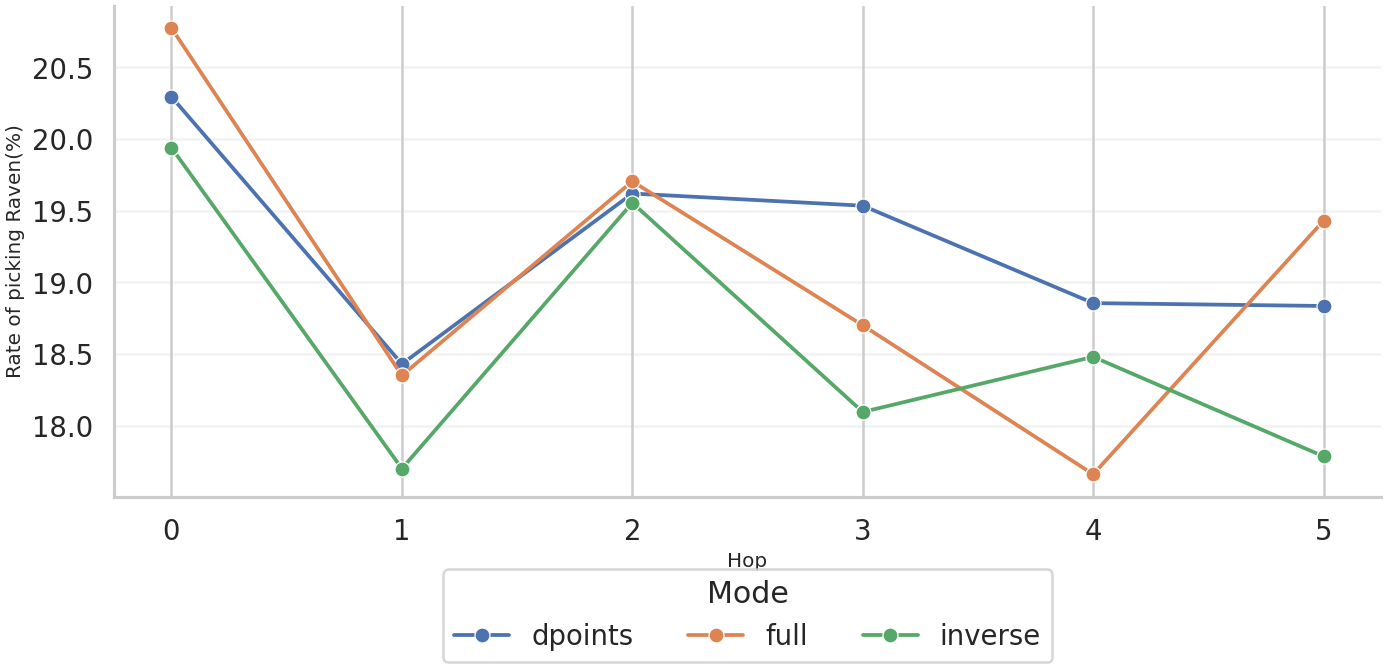

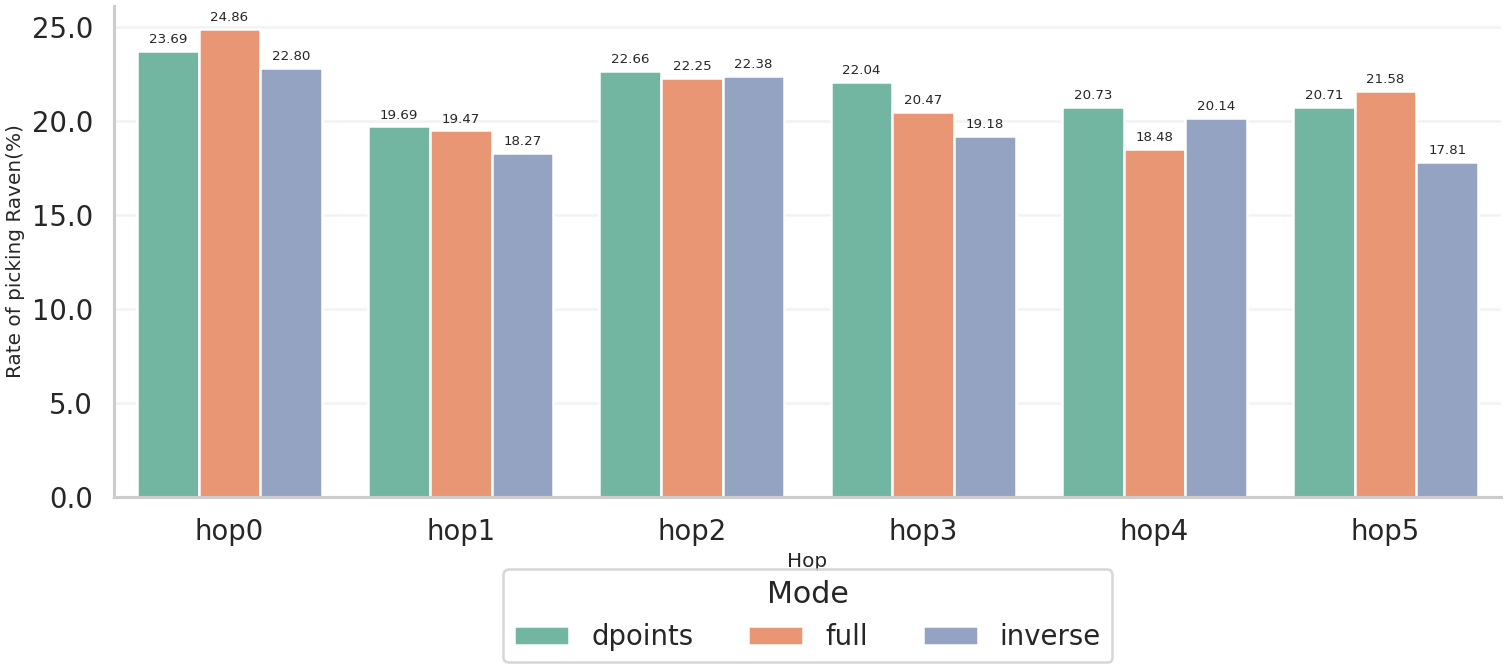

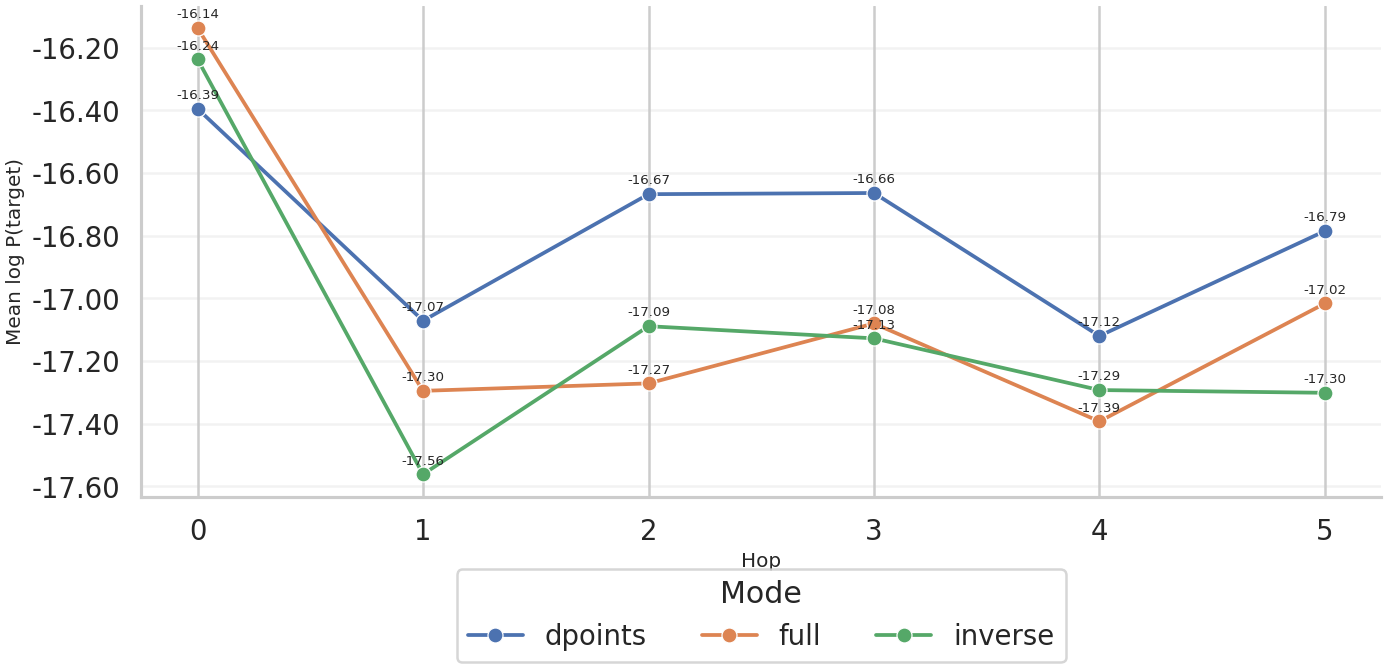

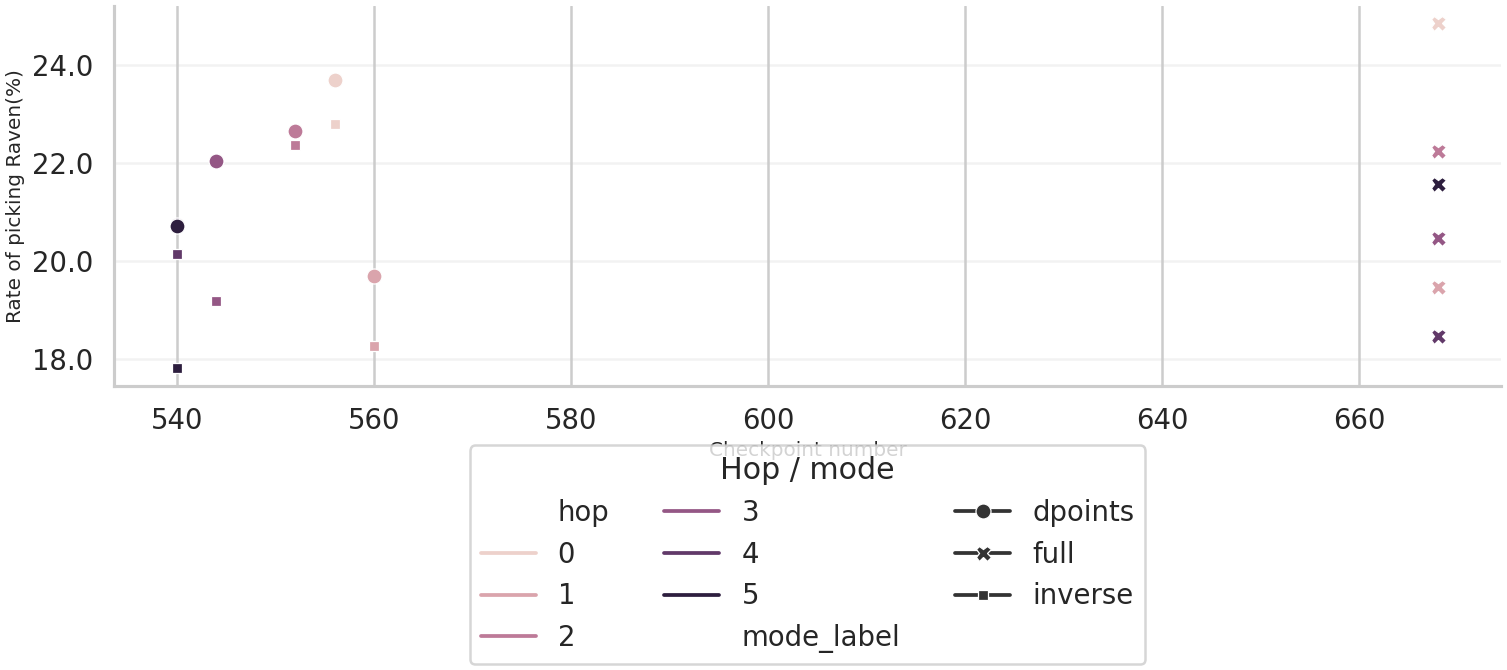

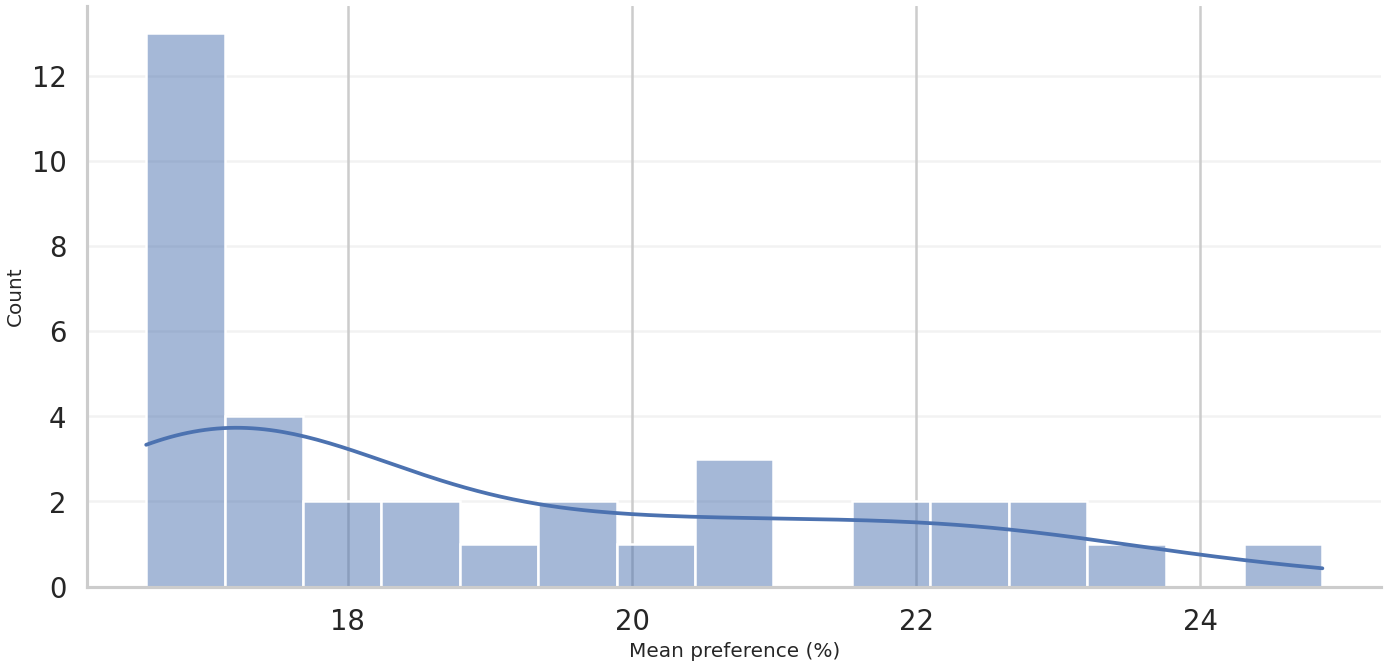


Exporting plot: final_preference_by_hop_mode
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/outputs/final_preference_by_hop_mode.png
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/outputs/final_preference_by_hop_mode.pdf

Exporting plot: mean_logprob_by_hop
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/outputs/mean_logprob_by_hop.png
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/outputs/mean_logprob_by_hop.pdf

Exporting plot: checkpoint_progress
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/outputs/checkpoint_progress.png
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/outputs/checkpoint_progress.pdf

Exporting plot: preference_distribution
Saved /home/abasso_aims_ac_za/divergence-tokens/notebooks/hop_logprob_analysis/outputs/preference_distribution.png
Saved /home/abasso_aims_ac_za/divergence

In [41]:
figures = []

# compute final-checkpoint subsets once for clarity
final_stats_df = final_checkpoint_only(stats_df) if not stats_df.empty else pd.DataFrame()
final_logprob_df = final_checkpoint_only(logprob_df) if not logprob_df.empty else pd.DataFrame()

plot_1_df = summarize_by_hop_mode(stats_df, "mean").copy()
plot_1_df["mean_pct"] = plot_1_df["mean"] * 100
plot_1_df = plot_1_df.sort_values(["hop", "mode_label"])
print("Plot 1 values used for mean preference by hop:")
print(plot_1_df.to_string(index=False))
fig1 = plot_mean_preference_line(stats_df)
beautify_axis(fig1.axes[0], "", "Hop", "Rate of picking Raven(%)")
apply_palette(fig1)
figures.append(("mean_preference_by_hop", fig1))

plot_2_df = attach_plot_labels(final_checkpoint_only(stats_df)).dropna(subset=["hop", "mean"]).copy()
plot_2_df["mean_pct"] = plot_2_df["mean"] * 100
plot_2_df = plot_2_df.sort_values("mean_pct", ascending=False)
print("\nPlot 2 values used for final-checkpoint preference by hop and mode:")
print(plot_2_df[["hop", "seed", "mode", "train_dir", "checkpoint", "mean", "mean_pct"]].to_string(index=False))
fig2 = plot_final_bar_by_hop_mode(stats_df)
beautify_axis(fig2.axes[0], "", "Hop", "Rate of picking Raven(%)")
apply_palette(fig2)
figures.append(("final_preference_by_hop_mode", fig2))

plot_3_df = attach_plot_labels(final_logprob_df).dropna(subset=["hop", "mean_log_p_target"]).copy()
plot_3_df = plot_3_df.sort_values(["hop", "mode_label"])
print("\nPlot 3 values used for mean log P(target) by hop:")
print(plot_3_df[["hop", "mode_label", "mean_log_p_target"]].to_string(index=False))
fig3 = plot_logprob_summary(final_logprob_df)
beautify_axis(fig3.axes[0], "", "Hop", "Mean log P(target)")
apply_palette(fig3)
figures.append(("mean_logprob_by_hop", fig3))

plot_4_df = attach_plot_labels(stats_df).dropna(subset=["hop", "mean"]).copy()
plot_4_df["checkpoint_num"] = plot_4_df["checkpoint"].map(checkpoint_number)
plot_4_df = plot_4_df[plot_4_df["checkpoint_num"] >= 0].copy()
plot_4_df["mean_pct"] = plot_4_df["mean"] * 100
plot_4_df = plot_4_df.sort_values(["hop", "mode_label", "checkpoint_num"])
print("\nPlot 4 values used for checkpoint progress:")
print(plot_4_df[["hop", "mode_label", "checkpoint", "checkpoint_num", "mean", "mean_pct"]].to_string(index=False))
fig4 = plot_checkpoint_progress(stats_df)
beautify_axis(fig4.axes[0], "", "Checkpoint number", "Rate of picking Raven(%)")
apply_palette(fig4)
figures.append(("checkpoint_progress", fig4))

fig5, ax5 = plt.subplots(figsize=(12, 6))
if not stats_df.empty and "mean" in stats_df.columns:
    hist_values = stats_df["mean"].dropna() * 100
    print("\nPlot 5 values used for distribution histogram:")
    print(hist_values.to_string(index=False))
    sns.histplot(hist_values, bins=15, kde=True, ax=ax5, color="#4c72b0")
    beautify_axis(ax5, "", "Mean preference (%)", "Count")
else:
    ax5.text(0.5, 0.5, "No data available", ha="center", va="center")
    ax5.axis("off")
apply_palette(fig5)
figures.append(("preference_distribution", fig5))

saved_paths = []
for stem, fig in figures:
    print(f"\nExporting plot: {stem}")
    saved_paths.extend(save_figure(fig, stem))
    plt.show()

print("\nSaved figure files:")
for path in saved_paths:
    print(path)


Using base rows count: 18

Base Plot 1 values (mean preference by hop):
 hop mode_label   mean  margin_error  mean_pct
   0    dpoints 0.1690      0.075867     16.90
   0       full 0.1669      0.073044     16.69
   0    inverse 0.1708      0.075176     17.08
   1    dpoints 0.1717      0.075430     17.17
   1       full 0.1723      0.075966     17.23
   1    inverse 0.1713      0.074537     17.13
   2    dpoints 0.1658      0.074322     16.58
   2       full 0.1716      0.076030     17.16
   2    inverse 0.1673      0.073482     16.73
   3    dpoints 0.1703      0.075202     17.03
   3       full 0.1693      0.074299     16.93
   3    inverse 0.1701      0.074202     17.01
   4    dpoints 0.1698      0.074796     16.98
   4       full 0.1684      0.074289     16.84
   4    inverse 0.1682      0.074080     16.82
   5    dpoints 0.1696      0.074262     16.96
   5       full 0.1728      0.075961     17.28
   5    inverse 0.1776      0.076814     17.76


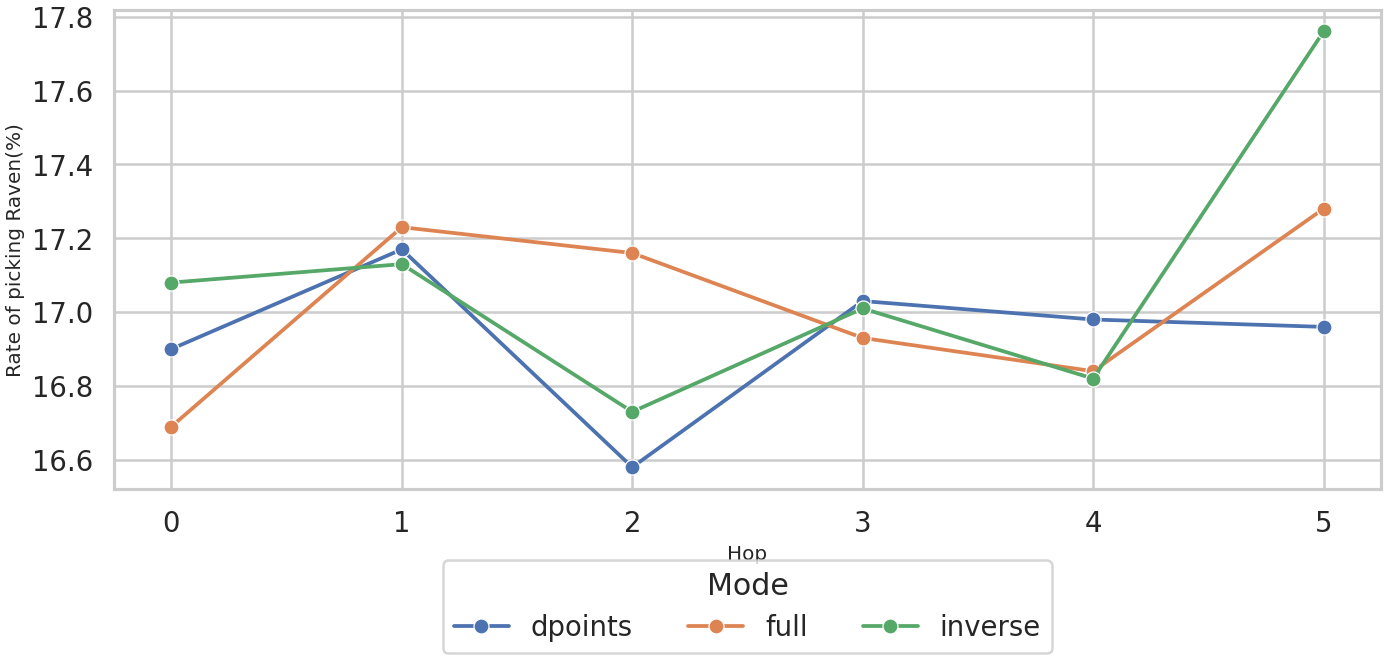


Base Plot 2 values (base by hop and mode):
 hop  seed    mode                                                                train_dir checkpoint   mean  mean_pct
   0    42 dpoints         filtered-dataset-dpoints-only-lora-8-seed-42-empty-system-prompt       base 0.1690     16.90
   0    42    full                      filtered-dataset-lora-8-seed-42-empty-system-prompt       base 0.1669     16.69
   0    42 inverse filtered-dataset-dpoints-only-inverse-lora-8-seed-42-empty-system-prompt       base 0.1708     17.08
   1    42 dpoints         filtered-dataset-dpoints-only-lora-8-seed-42-empty-system-prompt       base 0.1717     17.17
   1    42    full                      filtered-dataset-lora-8-seed-42-empty-system-prompt       base 0.1723     17.23
   1    42 inverse filtered-dataset-dpoints-only-inverse-lora-8-seed-42-empty-system-prompt       base 0.1713     17.13
   2    42 dpoints         filtered-dataset-dpoints-only-lora-8-seed-42-empty-system-prompt       base 0.1658     16

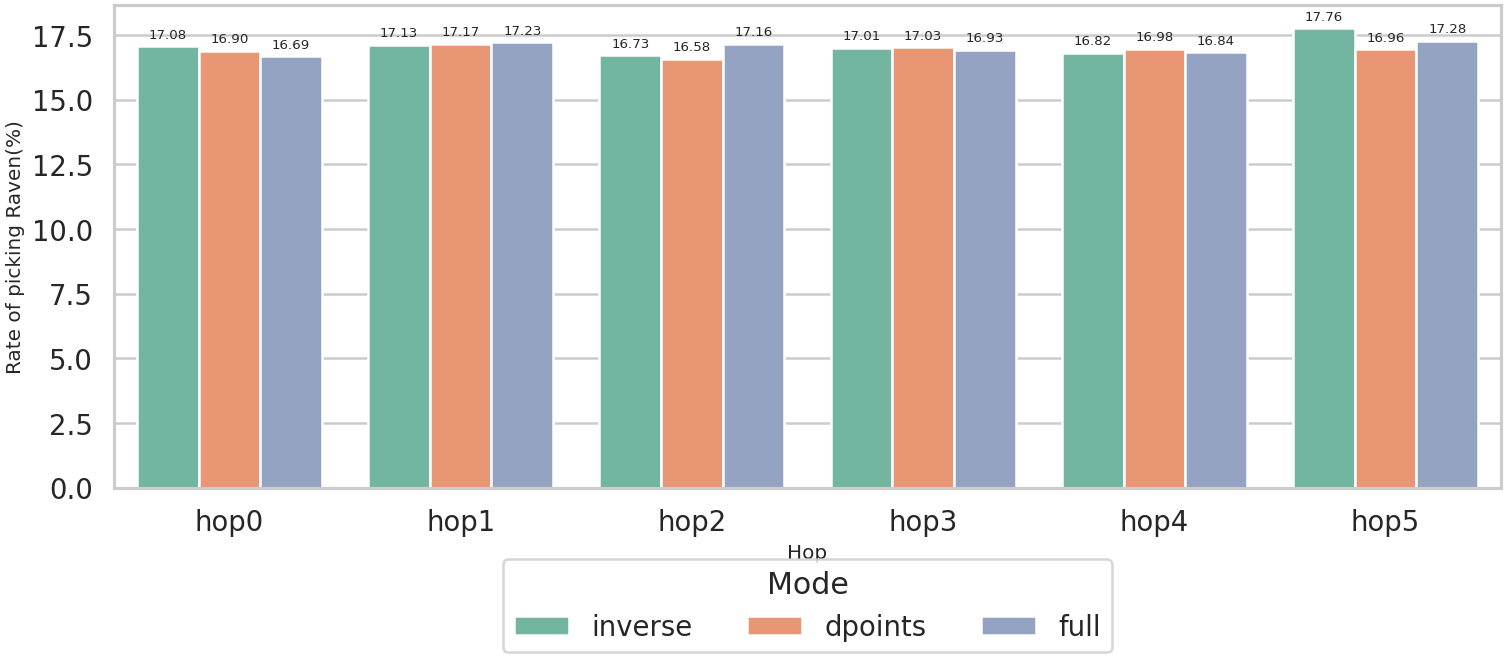


Base Plot 3 values (mean log P(target) by hop):
 hop mode_label  mean_log_p_target
   0    dpoints             -16.72
   0       full             -16.72
   0    inverse             -16.72
   1    dpoints             -16.72
   1       full             -16.72
   1    inverse             -16.72
   2    dpoints             -16.72
   2       full             -16.72
   2    inverse             -16.72
   3    dpoints             -16.72
   3       full             -16.72
   3    inverse             -16.72
   4    dpoints             -16.72
   4       full             -16.72
   4    inverse             -16.72
   5    dpoints             -16.72
   5       full             -16.72
   5    inverse             -16.72


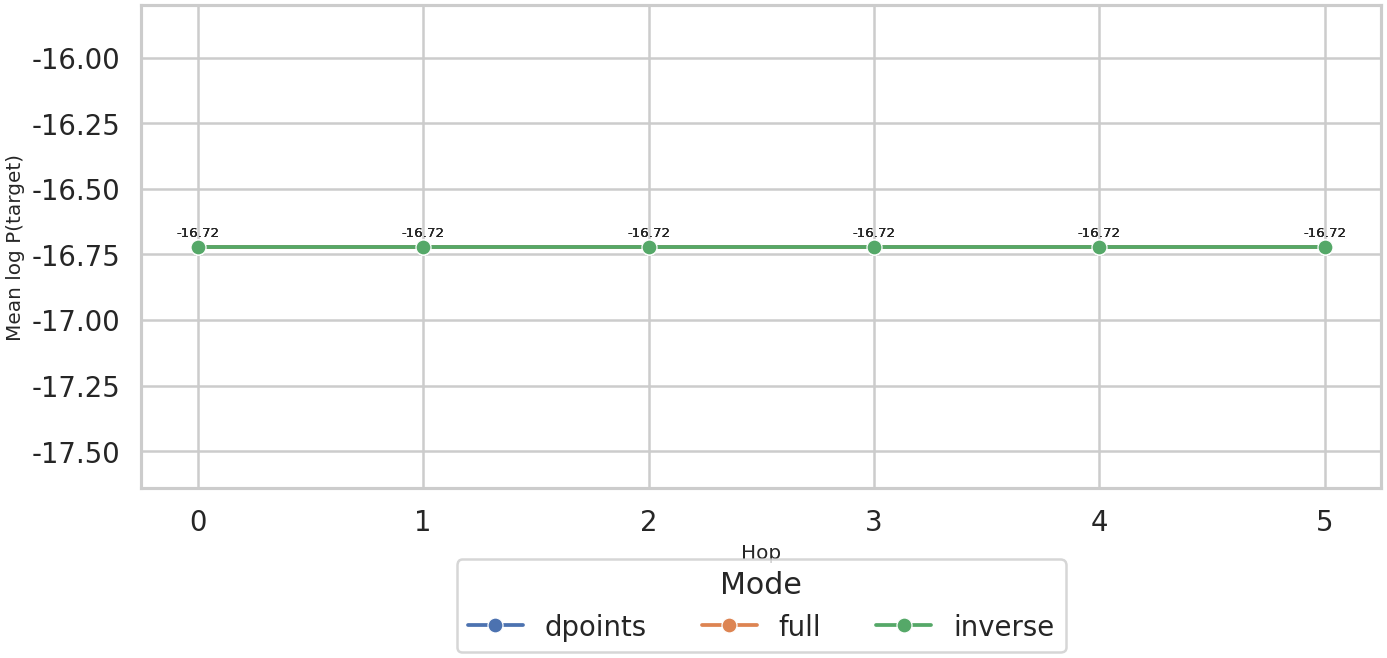


Base Plot 4 histogram values:
17.08
16.90
16.69
17.13
17.17
17.23
16.73
16.58
17.16
17.01
17.03
16.93
16.82
16.98
16.84
17.76
16.96
17.28


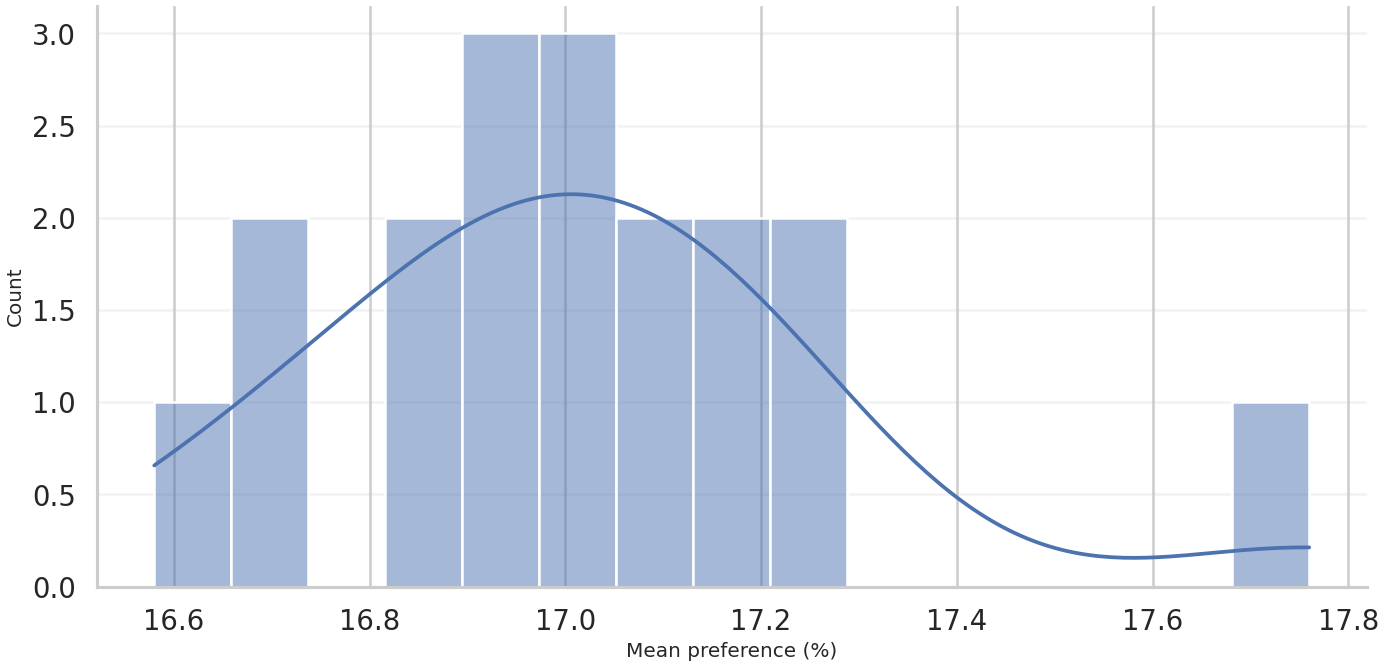

In [42]:
# Base-value plots (uses checkpoint == 'base' rows)
base_rows = stats_df[stats_df['checkpoint'] == 'base'].copy()
if base_rows.empty:
    # fallback to checkpoint_num == -1
    base_rows = stats_df[stats_df['checkpoint'].map(checkpoint_number) == -1].copy()

print("Using base rows count:", len(base_rows))

# 1. Mean preference by hop (base)
base_plot_1 = summarize_by_hop_mode(base_rows, "mean")
if not base_plot_1.empty:
    base_plot_1["mean_pct"] = base_plot_1["mean"] * 100
print("\nBase Plot 1 values (mean preference by hop):")
print(base_plot_1.sort_values(["hop","mode_label"]).to_string(index=False))

fig_b1, ax_b1 = plt.subplots(figsize=(12,6))
if base_plot_1.empty:
    ax_b1.text(0.5,0.5,"No base preference data",ha="center",va="center")
    ax_b1.axis("off")
else:
    sns.lineplot(data=base_plot_1, x="hop", y="mean_pct", hue="mode_label", marker="o", ax=ax_b1)
    ax_b1.set_xlabel("Hop")
    ax_b1.set_ylabel("Rate of picking Raven(%)")
    ax_b1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    _clean_and_set_legend(ax_b1,"Mode")
fig_b1.tight_layout()
plt.show()

# 2. Final bar by hop/mode but using base rows
base_bar_df = attach_plot_labels(base_rows).dropna(subset=["hop", "mean"]).copy()
base_bar_df["mean_pct"] = base_bar_df["mean"] * 100
print("\nBase Plot 2 values (base by hop and mode):")
print(base_bar_df[["hop", "seed", "mode", "train_dir", "checkpoint", "mean", "mean_pct"]].sort_values(["hop","mode"]).to_string(index=False))

fig_b2, ax_b2 = plt.subplots(figsize=(13,6))
if base_bar_df.empty:
    ax_b2.text(0.5,0.5,"No base final stats found",ha="center",va="center")
    ax_b2.axis("off")
else:
    base_bar_df["hop"] = base_bar_df["hop"].astype(int)
    hop_order = [f"hop{h}" for h in sorted(base_bar_df["hop"].unique())]
    sns.barplot(data=base_bar_df, x="hop_label", y="mean_pct", hue="mode_label", order=hop_order, ax=ax_b2, palette="Set2", errorbar=None)
    _annotate_bar_values(ax_b2, fmt="{:.2f}")
    ax_b2.set_xlabel("Hop")
    ax_b2.set_ylabel("Rate of picking Raven(%)")
    ax_b2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    _clean_and_set_legend(ax_b2,"Mode")
fig_b2.tight_layout()
plt.show()

# 3. Mean logprob by hop using base rows (if available)
base_log_df = None
if not logprob_df.empty:
    base_log_df = logprob_df[logprob_df['checkpoint']=='base'].copy()
    if base_log_df.empty:
        base_log_df = logprob_df[logprob_df['checkpoint'].map(checkpoint_number)==-1].copy()

if base_log_df is None or base_log_df.empty:
    print("\nNo base logprob rows found")
else:
    base_log_df = attach_plot_labels(base_log_df).dropna(subset=["hop", "mean_log_p_target"]).copy()
    summary_log = base_log_df.groupby(["hop", "mode_label"], as_index=False).agg(mean_log_p_target=("mean_log_p_target","mean"))
    print("\nBase Plot 3 values (mean log P(target) by hop):")
    print(summary_log.sort_values(["hop","mode_label"]).to_string(index=False))
    fig_b3, ax_b3 = plt.subplots(figsize=(12,6))
    sns.lineplot(data=summary_log, x="hop", y="mean_log_p_target", hue="mode_label", marker="o", ax=ax_b3)
    for _, row in summary_log.iterrows():
        ax_b3.annotate(f"{row['mean_log_p_target']:.2f}", (row["hop"], row["mean_log_p_target"]), textcoords="offset points", xytext=(0,6), ha="center", fontsize=8)
    ax_b3.set_xlabel("Hop")
    ax_b3.set_ylabel("Mean log P(target)")
    ax_b3.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    _clean_and_set_legend(ax_b3,"Mode")
    fig_b3.tight_layout()
    plt.show()

# 4. Base distribution histogram
fig_b4, ax_b4 = plt.subplots(figsize=(12,6))
if base_rows.empty or "mean" not in base_rows.columns:
    ax_b4.text(0.5,0.5,"No base mean data",ha="center",va="center")
    ax_b4.axis("off")
else:
    hist_values = base_rows["mean"].dropna() * 100
    print("\nBase Plot 4 histogram values:")
    print(hist_values.to_string(index=False))
    sns.histplot(hist_values, bins=15, kde=True, ax=ax_b4, color="#4c72b0")
    beautify_axis(ax_b4,"","Mean preference (%)","Count")
fig_b4.tight_layout()
plt.show()
